# Boundless Prover Profitability Model

**Core objective:** Assess the profitability of running a Boundless Prover under different ZKC prices, market utilization rates, and GPU configurations.

## Model Overview

To estimate profitability we use several inputs:
- GPU configurations - to adjust costs and MHz capacity
- ZKC prices - to model for different price points
- Market order utilization - to adjust for the % of GPU capacity that is spent on market orders, which determines market rewards
- Market reward rate - average USD per MHz expected from the market

All costs, revenue, and profit are expressed per epoch and primarily denominated in USD.

## How to run

1. Install dependencies: `pip install -r requirements.txt`
2. Edit the **1.1 Model Parameters** section to adjust the model parameters
3. (Optional) Fetch the latest epoch data:
    - Goto https://explorer.boundless.network/epochs
    - In the top right click "Export CSV"
    - Replace `epochs.csv` with the new copy
3. To run this locally: `jupyter notebook` will launch the web interface. Google Collab can also be used to run this online.

## 1. Inputs

This section defines the core setup for the model, split into three parts:

1. **Model Parameters**: Tunable inputs for the model. (EDIT THESE).
2. **Constants**: Fixed values required for calculation (DO NOT EDIT).
3. **POVW Reward Data**: Parsing logic that derives `POVW_ZKC_PER_MHZ_PER_EPOCH` from historical epochs data (epochs.csv).

### 1.1 Model Parameters (EDIT THESE)

`ZKC_PRICES_USD`

The model will use each value as a possible scenario for the price of ZKC. Pick any values you want.

`MARKET_ORDER_UTIL`

A percentage of the GPU capacity the is used for market orders. Pick any values you want. (Note: utilization tends to be <50%)

`MARKET_REWARD_USD_PER_MHZ`

Expected price paid per million cycles on the market. Can be estimated from [market stats](https://explorer.boundless.network/stats), (see "Lock price per cycle distribution"). You can divide USD/Bcycle by 1000 to get USD/Mhz.

`FIXED_COST_MONTHLY_USD`

Any additional expenses, fixed cost per month.

`gpu_configs`

List of GPU options to model.

In [60]:
import pandas as pd
import numpy as np
import re

# ZKC prices (USD per ZKC) to model
ZKC_PRICES_USD = [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.3, 0.5, 1.0]

# Market order utilization: percentage of capacity used for fulfilling market orders.
MARKET_ORDER_UTIL = [0.25, 0.5, 0.75, 1.0]

# Average reward per million cycles in USD
MARKET_REWARD_USD_PER_MHZ = 0.00007

# Fixed cost additional expenses
FIXED_COST_MONTHLY_USD = 0

# GPU configurations
gpu_configs = pd.DataFrame([
    {"label": "RTX5090 x 8", "num_gpus": 8, "usd_per_hour": 0.50, "mhz": 1.1},
    {"label": "RTX5090 x 4", "num_gpus": 4, "usd_per_hour": 0.55, "mhz": 1.1},
    {"label": "RTX4090 x 8", "num_gpus": 8, "usd_per_hour": 0.40, "mhz": 0.9},
])

### 1.2 Constants (DO NOT EDIT)

In [61]:
# Epoch: 48 hours. ~15 epochs per 30-day month.
HOURS_PER_EPOCH = 48
SECONDS_PER_EPOCH = HOURS_PER_EPOCH * 3600  # 172800
EPOCHS_PER_MONTH = 30 * 24 / HOURS_PER_EPOCH  # 15

In [62]:
# Additional Calculations (DO NOT EDIT)
fixed_cost_per_epoch = FIXED_COST_MONTHLY_USD / EPOCHS_PER_MONTH
gpu_configs["rental_per_epoch_usd"] = gpu_configs["usd_per_hour"] * gpu_configs["num_gpus"] * HOURS_PER_EPOCH
# Million cycles per epoch = mhz (per sec) * seconds per epoch
gpu_configs["mhz_per_epoch"] = gpu_configs["mhz"] * SECONDS_PER_EPOCH

gpu_configs["cost_per_mhz_usd"] = gpu_configs["rental_per_epoch_usd"] / gpu_configs["mhz_per_epoch"]

gpu_configs["total_cost_epoch"] = gpu_configs["rental_per_epoch_usd"] + fixed_cost_per_epoch

cost_summary = gpu_configs[
    ["label", "num_gpus", "rental_per_epoch_usd", "total_cost_epoch", "cost_per_mhz_usd"]
].copy()
cost_summary

,label,num_gpus,rental_per_epoch_usd,total_cost_epoch,cost_per_mhz_usd
0,RTX5090 x 8,8,192.0,192.0,0.001010
1,RTX5090 x 4,4,105.6,105.6,0.000556
2,RTX4090 x 8,8,153.6,153.6,0.000988


### 1.3 POVW Reward Data

Using historical data (epochs.csv) we compute the average (mean) ZKC reward per million cycles.

We ignore the latest epoch as it is ongoing. `EPOCH_LOOKBACK_COUNT` can be adjusted to set the number of most recent epochs used in the calculation.

In [63]:
EPOCH_LOOKBACK_COUNT=10

def parse_cycles(s):
    """Parse Total Cycles string (e.g. '664T', '791M', '0') to cycle count."""
    s = str(s).strip().upper().replace(",", "")
    if not s or s == "0":
        return 0.0
    m = re.match(r"^([\d.]+)\s*([TGMK]?)$", s)
    if not m:
        return np.nan
    val = float(m.group(1))
    suffix = m.group(2) or ""
    mult = {"T": 1e12, "G": 1e9, "M": 1e6, "K": 1e3}.get(suffix, 1)
    return val * mult


def parse_zkc(s):
    """Parse Mining Rewards string (e.g. '288K ZKC', '96,011 ZKC') to ZKC amount."""
    s = str(s).strip().replace(",", "").replace(" ZKC", "").upper()
    if not s or s == "0":
        return 0.0
    m = re.match(r"^([\d.]+)\s*([KMB]?)$", s)
    if not m:
        return np.nan
    val = float(m.group(1))
    suffix = m.group(2) or ""
    mult = {"B": 1e9, "M": 1e6, "K": 1e3}.get(suffix, 1)
    return val * mult


epochs = pd.read_csv("epochs.csv")
# Exclude latest epoch (first row): still ongoing, incomplete.
epochs_complete = epochs.iloc[1:].copy()
# Parse units
epochs_complete["total_cycles"] = epochs_complete["Total Cycles"].map(parse_cycles)
epochs_complete["mining_rewards_zkc"] = epochs_complete["Mining Rewards (ZKC)"].map(parse_zkc)
# Convert cycles => mhz
epochs_complete["mhz"] = epochs_complete["total_cycles"] / 1e6  # million cycles
# Compute zkc_per_mhz
epochs_complete["zkc_per_mhz"] = np.where(
    epochs_complete["mhz"] > 0,
    epochs_complete["mining_rewards_zkc"] / epochs_complete["mhz"],
    np.nan,
)

# Use only EPOCH_LOOKBACK_COUNT most recent completed epochs to avoid older values skewing the mean
epochs_for_povw = epochs_complete.head(EPOCH_LOOKBACK_COUNT)
POVW_ZKC_PER_MHZ_PER_EPOCH = epochs_for_povw["zkc_per_mhz"].mean()

# Display table showing parsed data for each epoch
epochs_complete[["Epoch", "mining_rewards_zkc", "mhz", "zkc_per_mhz"]].rename(
    columns={"mining_rewards_zkc": "ZKC"}
)

,Epoch,ZKC,mhz,zkc_per_mhz
1,90,288000.0,729000000.0,0.000395
2,89,288000.0,736000000.0,0.000391
3,88,288000.0,607000000.0,0.000474
4,87,288000.0,699000000.0,0.000412
5,86,287000.0,729000000.0,0.000394
...,...,...,...,...
87,4,132000.0,24000000.0,0.005500
88,3,40000.0,22000000.0,0.001818
89,2,9000.0,3000000.0,0.003000
90,1,6000.0,791.0,7.585335


## 2. Compute Cost, Revenue, Profit

**Profit per epoch** = total revenue − total cost (GPU + fixed).

In [64]:
results = []
for _, row in gpu_configs.iterrows():
    mhz_per_epoch = row["mhz_per_epoch"]
    total_cost_epoch = row["total_cost_epoch"]
    scenario = row["label"]
    for zkc_price in ZKC_PRICES_USD:
        povw_revenue = mhz_per_epoch * POVW_ZKC_PER_MHZ_PER_EPOCH * zkc_price
        for market_order_util in MARKET_ORDER_UTIL:
            market_revenue = mhz_per_epoch * MARKET_REWARD_USD_PER_MHZ * market_order_util
            total_revenue = povw_revenue + market_revenue
            profit = total_revenue - total_cost_epoch
            results.append({
                "scenario": scenario,
                "label": row["label"],
                "num_gpus": row["num_gpus"],
                "zkc_price_usd": zkc_price,
                "market_order_util": market_order_util,
                "mhz_per_epoch": mhz_per_epoch,
                "cost_per_epoch": total_cost_epoch,
                "povw_revenue": povw_revenue,
                "market_revenue": market_revenue,
                "total_revenue": total_revenue,
                "profit_per_epoch": profit,
            })

revenue_df = pd.DataFrame(results)
# Display all data
revenue_df

,scenario,label,num_gpus,zkc_price_usd,market_order_util,mhz_per_epoch,cost_per_epoch,povw_revenue,market_revenue,total_revenue,profit_per_epoch
0,RTX5090 x 8,RTX5090 x 8,8,0.025,0.25,190080.0,192.0,1.885730,3.3264,5.212130,-186.787870
1,RTX5090 x 8,RTX5090 x 8,8,0.025,0.50,190080.0,192.0,1.885730,6.6528,8.538530,-183.461470
2,RTX5090 x 8,RTX5090 x 8,8,0.025,0.75,190080.0,192.0,1.885730,9.9792,11.864930,-180.135070
3,RTX5090 x 8,RTX5090 x 8,8,0.025,1.00,190080.0,192.0,1.885730,13.3056,15.191330,-176.808670
4,RTX5090 x 8,RTX5090 x 8,8,0.050,0.25,190080.0,192.0,3.771459,3.3264,7.097859,-184.902141
...,...,...,...,...,...,...,...,...,...,...,...
115,RTX4090 x 8,RTX4090 x 8,8,0.500,1.00,155520.0,153.6,30.857395,10.8864,41.743795,-111.856205
116,RTX4090 x 8,RTX4090 x 8,8,1.000,0.25,155520.0,153.6,61.714790,2.7216,64.436390,-89.163610
117,RTX4090 x 8,RTX4090 x 8,8,1.000,0.50,155520.0,153.6,61.714790,5.4432,67.157990,-86.442010
118,RTX4090 x 8,RTX4090 x 8,8,1.000,0.75,155520.0,153.6,61.714790,8.1648,69.879590,-83.720410


In [65]:
# Display summary of data
revenue_df[["scenario", "zkc_price_usd", "market_order_util", "profit_per_epoch"]]

,scenario,zkc_price_usd,market_order_util,profit_per_epoch
0,RTX5090 x 8,0.025,0.25,-186.787870
1,RTX5090 x 8,0.025,0.50,-183.461470
2,RTX5090 x 8,0.025,0.75,-180.135070
3,RTX5090 x 8,0.025,1.00,-176.808670
4,RTX5090 x 8,0.050,0.25,-184.902141
...,...,...,...,...
115,RTX4090 x 8,0.500,1.00,-111.856205
116,RTX4090 x 8,1.000,0.25,-89.163610
117,RTX4090 x 8,1.000,0.50,-86.442010
118,RTX4090 x 8,1.000,0.75,-83.720410


## 3. Visualize results

### 3.1 Raw Results

In [66]:
profit_pivot = revenue_df.pivot_table(
    index=["scenario", "market_order_util"], columns="zkc_price_usd", values="profit_per_epoch"
)
profit_pivot

zkc_price_usd                      0.025       0.050       0.075       0.100  \
scenario    market_order_util                                                  
RTX4090 x 8 0.25              -149.33553 -147.792661 -146.249791 -144.706921   
            0.50              -146.61393 -145.071061 -143.528191 -141.985321   
            0.75              -143.89233 -142.349461 -140.806591 -139.263721   
            1.00              -141.17073 -139.627861 -138.084991 -136.542121   
RTX5090 x 4 0.25              -100.38787  -98.502141  -96.616411  -94.730681   
            0.50               -97.06147  -95.175741  -93.290011  -91.404281   
            0.75               -93.73507  -91.849341  -89.963611  -88.077881   
            1.00               -90.40867  -88.522941  -86.637211  -84.751481   
RTX5090 x 8 0.25              -186.78787 -184.902141 -183.016411 -181.130681   
            0.50              -183.46147 -181.575741 -179.690011 -177.804281   
            0.75              -180.13507 -178.249341 -176.363611 -174.477881   
            1.00              -176.80867 -174.922941 -173.037211 -171.151481   

zkc_price_usd                       0.125       0.150       0.200       0.300  \
scenario    market_order_util                                                   
RTX4090 x 8 0.25              -143.164051 -141.621182 -138.535442 -132.363963   
            0.50              -140.442451 -138.899582 -135.813842 -129.642363   
            0.75              -137.720851 -136.177982 -133.092242 -126.920763   
            1.00              -134.999251 -133.456382 -130.370642 -124.199163   
RTX5090 x 4 0.25               -92.844952  -90.959222  -87.187763  -79.644844   
            0.50               -89.518552  -87.632822  -83.861363  -76.318444   
            0.75               -86.192152  -84.306422  -80.534963  -72.992044   
            1.00               -82.865752  -80.980022  -77.208563  -69.665644   
RTX5090 x 8 0.25              -179.244952 -177.359222 -173.587763 -166.044844   
            0.50              -175.918552 -174.032822 -170.261363 -162.718444   
            0.75              -172.592152 -170.706422 -166.934963 -159.392044   
            1.00              -169.265752 -167.380022 -163.608563 -156.065644   

zkc_price_usd                       0.500       1.000  
scenario    market_order_util                          
RTX4090 x 8 0.25              -120.021005  -89.163610  
            0.50              -117.299405  -86.442010  
            0.75              -114.577805  -83.720410  
            1.00              -111.856205  -80.998810  
RTX5090 x 4 0.25               -64.559006  -26.844413  
            0.50               -61.232606  -23.518013  
            0.75               -57.906206  -20.191613  
            1.00               -54.579806  -16.865213  
RTX5090 x 8 0.25              -150.959006 -113.244413  
            0.50              -147.632606 -109.918013  
            0.75              -144.306206 -106.591613  
            1.00              -140.979806 -103.265213

### 3.2 Scenario Graphs

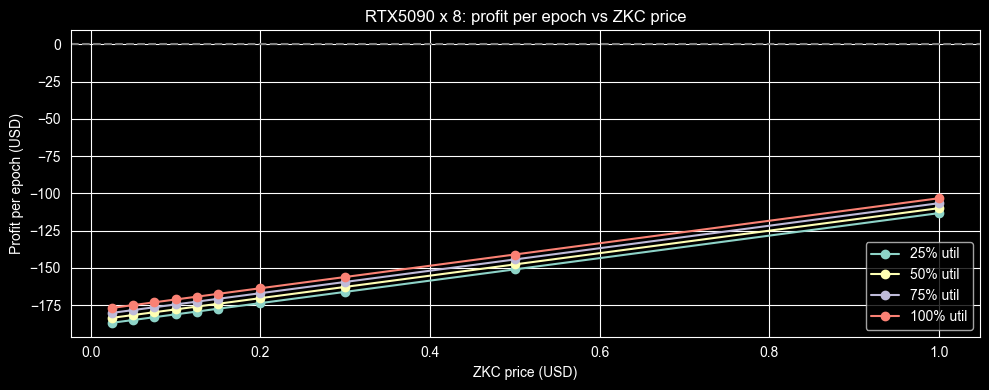

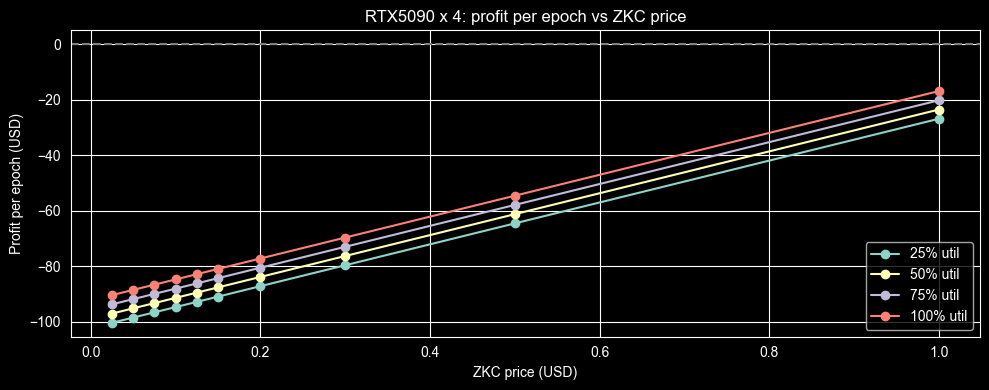

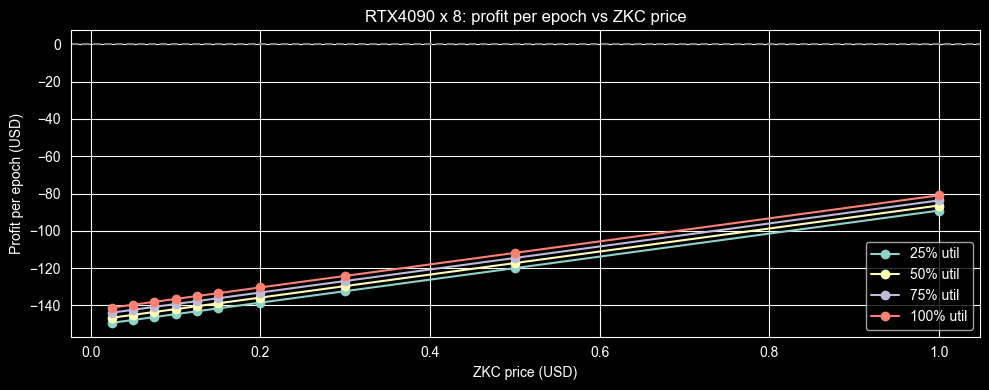

In [68]:
%matplotlib inline
import matplotlib.pyplot as plt

# One graph per GPU config; each shows profit vs ZKC price with one line per market order utilization
for scenario in revenue_df["scenario"].unique():
    fig, ax = plt.subplots(figsize=(10, 4))
    scenario_df = revenue_df[revenue_df["scenario"] == scenario]
    for util, sub in scenario_df.groupby("market_order_util"):
        ax.plot(sub["zkc_price_usd"], sub["profit_per_epoch"], marker="o", label=f"{util * 100:.0f}% util")
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_xlabel("ZKC price (USD)")
    ax.set_ylabel("Profit per epoch (USD)")
    ax.set_title(f"{scenario}: profit per epoch vs ZKC price")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 3.3 Profitable scenarios (profit_per_epoch > 0)

Pivot table filtered to only show scenarios with positive `profit_per_epoch`.

In [67]:
# Pivot table: profitable scenarios only (profit_per_epoch > 0)
profitable_revenue_df = revenue_df[revenue_df["profit_per_epoch"] > 0].copy()

if profitable_revenue_df.empty:
    print("No profitable scenarios for current inputs (profit_per_epoch <= 0 everywhere).")
else:
    profitable_pivot = profitable_revenue_df.pivot_table(
        index=["scenario", "market_order_util"],
        columns="zkc_price_usd",
        values="profit_per_epoch",
    )
    profitable_pivot

No profitable scenarios for current inputs (profit_per_epoch <= 0 everywhere).
